In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Project: Ecommerce Sales Analysis
## Objective: 
The objective is to analyze sales trends across products, categories, and regions, 
identify top-selling products and seasonal patterns, and provide insights to improve 
sales and business decisions. 
Data Description: 
The dataset contains order-level sales information for an e-commerce platform. It includes the 
following columns: 
1. **order_id** – Unique identifier for each order. 
2. **product** – Name of the product sold (e.g., Watch, Bag, Shoes). 
3. **category** – Product category (e.g., Electronics, Fashion). 
4. **price** – Price of a single unit of the product. 
5. **quantity** – Number of units purchased in the order. 
6. **payment_method** – Payment method used (e.g., Easypaisa, Credit Card, JazzCash). 
7. **date** – Date of the order. 
8. **total** – Total order value (price × quantity). 
9. **Month** – Month when the order was placed. 
10. **Discount** – Discount applied to the order (if any). 
11. **City Code** – Numeric code representing the city of the buyer: 
 1 = Karachi 
 2 = Lahore 
 3 = Islamabad 
 4 = Faisalabad 
 5 = Quetta 
 6 = Peshawar 
12. **Order Priority Code** – Numeric code representing order priority: 
 0 = LOW 
 1 = MEDIUM 
 2 = HIGH 
 3 = CRITICAL 
13. **Latitude** – Latitude of the buyer’s location. 
14. **Longitude** – Longitude of the buyer’s location. 

# Data Preprocessing and Wrangling 
1. *Load the dataset using Python Library Pandas* 
2. *Check types of data*  
3. *Drop irrelevant columns (Latitude, Longitude)* 
4. *Rename columns City Code to City & Order Priority Code to Order Priority*
5. *Check duplicate rows* 
6. *Drop duplicate records* 
7. *Check missing and null values*  
8. *Fill missing sales value by their median*

In [5]:
df = pd.read_csv('ecommerce_dataset.csv')
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0,1.0,0.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0,1.0,0.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0,1.0,0.0


In [6]:
df.columns

Index(['order_id', 'product', 'category', 'price', 'quantity',
       'payment_method', 'date', 'total', 'Month', 'Discount', 'City Code',
       'Order Priority Code', 'Latitude', 'Longtitude'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             506 non-null    int64  
 1   product              506 non-null    object 
 2   category             506 non-null    object 
 3   price                506 non-null    float64
 4   quantity             506 non-null    int64  
 5   payment_method       506 non-null    object 
 6   date                 506 non-null    object 
 7   total                506 non-null    float64
 8   Month                506 non-null    object 
 9   Discount             506 non-null    float64
 10  City Code            491 non-null    float64
 11  Order Priority Code  487 non-null    float64
 12  Latitude             506 non-null    float64
 13  Longtitude           506 non-null    float64
dtypes: float64(7), int64(2), object(5)
memory usage: 55.5+ KB


In [9]:
df.product

<bound method DataFrame.prod of      order_id     product     category     price  quantity payment_method  \
0           1       Watch  Electronics  12652.30         4      Easypaisa   
1           2         Bag      Fashion  20053.64         2    Credit Card   
2           3       Shoes      Fashion  13274.17         2       JazzCash   
3           4         Bag  Electronics  15332.08         1            COD   
4           5         Bag  Accessories  23165.07         1     Debit Card   
..        ...         ...          ...       ...       ...            ...   
501         4         Bag  Electronics  15332.08         1            COD   
502        18  Headphones  Electronics  14085.56         2     Debit Card   
503        19      Laptop  Accessories  53657.14         4     Debit Card   
504        20       Watch      Fashion  74385.39         4    Credit Card   
505        21         Bag  Electronics  44762.65         4            COD   

           date      total    Month  Discou

In [16]:
df.dtypes

order_id                 int64
product                 object
category                object
price                  float64
quantity                 int64
payment_method          object
date                    object
total                  float64
Month                   object
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object

In [20]:
df = df.drop(columns=["Latitude", "Longtitude"])

In [21]:
df.columns

Index(['order_id', 'product', 'category', 'price', 'quantity',
       'payment_method', 'date', 'total', 'Month', 'Discount', 'City Code',
       'Order Priority Code'],
      dtype='object')

In [22]:
df = df.rename(columns={"City Code":"City", "Order Priority Code":"Order Priority"})

In [23]:
df.columns

Index(['order_id', 'product', 'category', 'price', 'quantity',
       'payment_method', 'date', 'total', 'Month', 'Discount', 'City',
       'Order Priority'],
      dtype='object')

In [25]:
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0


In [28]:
duplicates = df[df.duplicated()]
duplicates

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
500,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0
505,21,Bag,Electronics,44762.65,4,COD,21/01/2023,179050.60,January,0.0,1.0,2.0


In [29]:
df = df.drop_duplicates()

In [30]:
duplicates = df[df.duplicated()]
duplicates

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority


In [32]:
df.isnull().sum()

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64

In [34]:
df["City"] = df["City"].fillna(df["City"].median())

In [35]:
df.isnull().sum()

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City               0
Order Priority    19
dtype: int64

In [36]:
df["Order Priority"] = df["Order Priority"].fillna(df["Order Priority"].median())

In [37]:
df.isnull().sum()

order_id          0
product           0
category          0
price             0
quantity          0
payment_method    0
date              0
total             0
Month             0
Discount          0
City              0
Order Priority    0
dtype: int64

## Exploratory Data Analysis (Key Observations) 
### 1) Top 5 Best Selling Products 
### a) Write Observation 
### b) (Bar Chart) Using Seaborn 

In [41]:
top_5_products = (df.groupby("product")["quantity"].sum().sort_values(ascending=False).head(5))

In [42]:
top_5_products

product
Watch         256
Mobile        230
Headphones    227
Bag           189
Shoes         188
Name: quantity, dtype: int64

## Observation

#### The Watch is the best-selling product with 256 units sold, followed by Mobile (230 units) and Headphones (227 units). Bag (189 units) and Shoes (188 units) have the lowest sales among the top five products. Overall, Watches show the strongest customer demand, while Shoes have the weakest sales within this group.

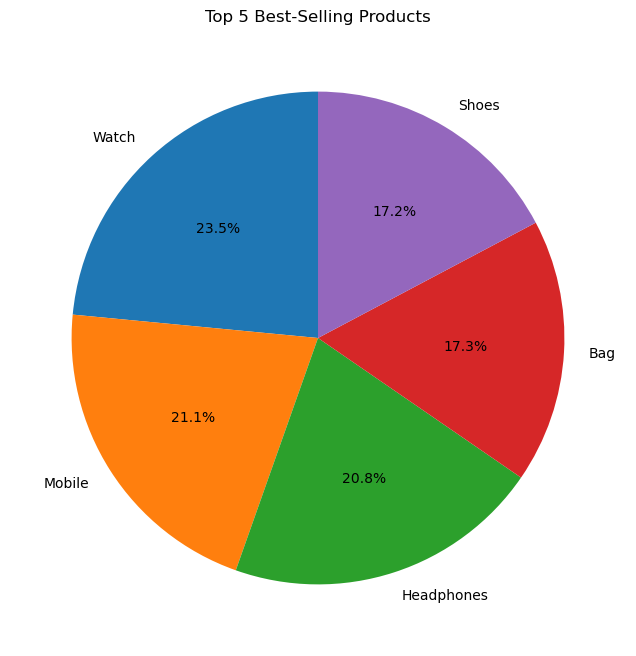

In [45]:
plt.figure(figsize=(8, 8))
plt.pie(top_5_products,labels=top_5_products.index,autopct="%1.1f%%",startangle=90)
plt.title("Top 5 Best-Selling Products")
plt.show()

# 2) Payment Method Distribution 
## a) Write Observation 
## b) (Pie Chart) Using Matplotlib

In [49]:
payment_counts = df["payment_method"].value_counts()
payment_counts

payment_method
JazzCash       112
Credit Card    107
Easypaisa      105
COD             97
Debit Card      79
Name: count, dtype: int64

## Observation

##### JazzCash is the most commonly used payment method with 112 transactions, followed by Credit Card (107) and Easypaisa (105). COD accounts for 97 transactions, while Debit Card is the least-used method with 79 transactions. Overall, digital payment methods are more popular than COD, with JazzCash being the leading option.

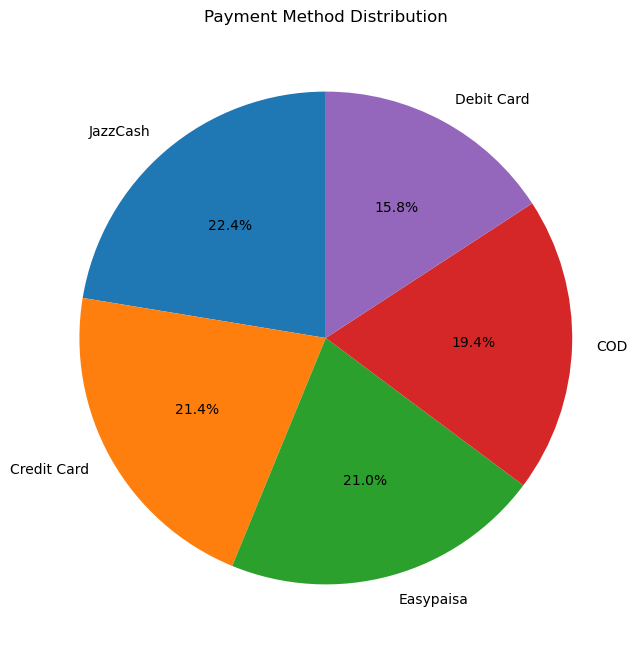

In [50]:
plt.figure(figsize=(8, 8))

plt.pie(payment_counts,labels=payment_counts.index,autopct="%1.1f%%", startangle=90)
plt.title("Payment Method Distribution")
plt.show()

## 3) Month-wise Sales 
### a) Write Observation 
### b) (Line Chart) Using Matplotlib

In [51]:
month_sales = df.groupby("Month")["total"].sum()
month_sales

Month
April        6275753.74
August       2557288.54
December     3952563.75
February     5545040.22
January      6238414.59
July         2688475.62
June         2860920.11
March        6711119.66
May          5909845.92
November     2805153.37
October      3139444.82
September    2515916.08
Name: total, dtype: float64

## Observation
#### March had the highest sales at approximately 6.71 million, while September had the lowest sales at approximately 2.52 million. Sales were generally higher from January to May, with March being the peak month. After May, sales declined considerably, reaching their lowest level in September, followed by a gradual recovery toward December.

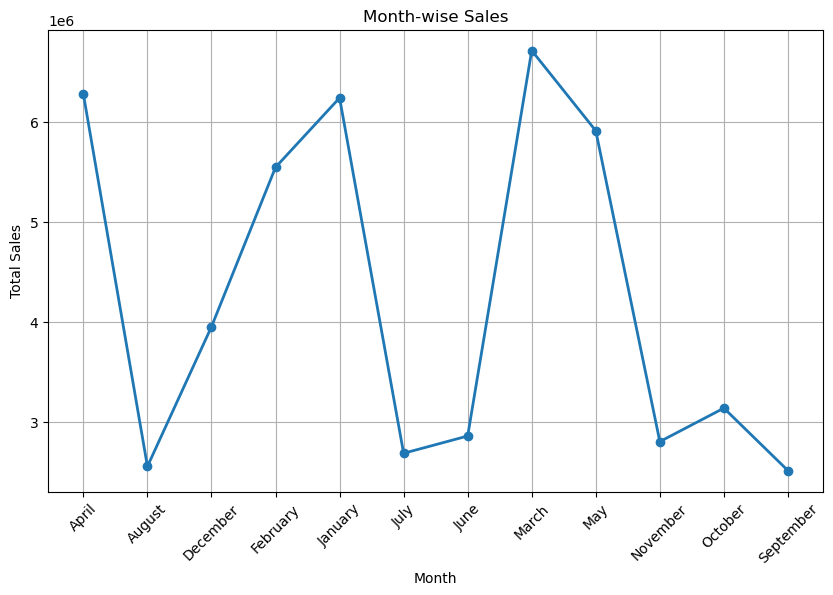

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(month_sales.index, month_sales.values, marker="o", linewidth=2)

plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## 4) Show City wise sales 
#### a) Replace City Names  
#### b) Horizontal Bar Chart using Seaborn 
#### c) Write Observation

In [68]:
df["City"] = df["City"].replace({ 1: "Karachi",   2: "Lahore",  3: "Islamabad",  4: "Faisalabad",  5: "Quetta", 6: "Peshawar"})

In [69]:
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.00,Karachi,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.10,Karachi,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.10,Karachi,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.10,Karachi,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.00,Karachi,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Watch,Electronics,66152.43,2,JazzCash,10/05/2024,132304.86,May,0.65,Faisalabad,1.0
496,497,Laptop,Electronics,10745.15,2,Easypaisa,11/05/2024,21490.30,May,0.70,Faisalabad,1.0
497,498,Laptop,Electronics,27141.95,1,JazzCash,12/05/2024,27141.95,May,0.70,Faisalabad,1.0
498,499,Bag,Fashion,59608.91,3,Credit Card,13/05/2024,178826.73,May,0.80,Faisalabad,1.0


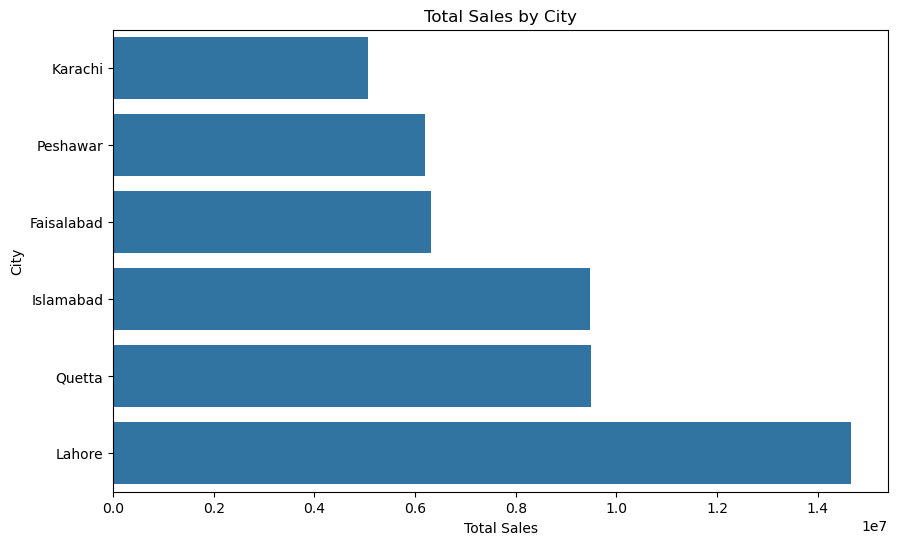

In [71]:
city_sales = df.groupby("City")["total"].sum().sort_values(ascending=True)


plt.figure(figsize=(10, 6))

sns.barplot(x=city_sales.values, y=city_sales.index)

plt.title("Total Sales by City")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.show()

## Observation

#### The horizontal bar chart shows the total sales across different cities. It helps identify which cities generate the highest and lowest sales. The city with the longest bar has the highest total sales, while the city with the shortest bar has the lowest total sales. Overall, there is a noticeable difference in sales performance among the cities.

## 5) Show monthly Sales by Category  
#### a) Side by side bar chart using matplotlib 
#### b) Write Observation

In [74]:
monthly_category_sales = (df.groupby(["Month", "category"], observed=True)["total"]  .sum() .reset_index())

monthly_category_sales

,Month,category,total
0,April,Accessories,2387980.38
1,April,Electronics,2265079.20
2,April,Fashion,1622694.16
3,August,Accessories,521529.94
4,August,Electronics,881950.11
5,August,Fashion,1153808.49
6,December,Accessories,1005459.07
7,December,Electronics,1460885.05
8,December,Fashion,1486219.63
9,February,Accessories,1178881.69


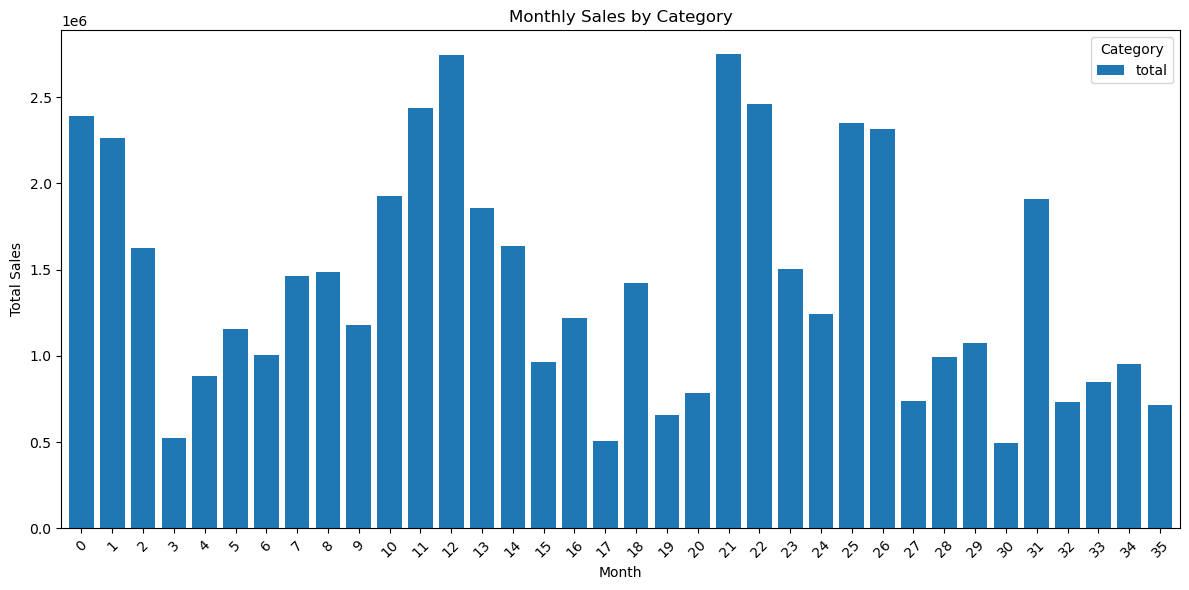

In [76]:
ax = monthly_category_sales.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.tight_layout()

plt.show()

## Observation

#### The side by side bar chart shows the monthly sales performance of different product categories. Sales vary across both months and categories, with some categories performing better than others during particular months. Overall, the chart helps identify which categories contribute the most to sales and how their performance changes throughout the year.